In [1]:
import numpy as np
import math

# toy grid for verification
z = np.array([
    [1, 2, 3, 4, 3, 2, 1],
    [1, 2, 4, 5, 4, 2, 1],
    [1, 3, 4, 6, 4, 3, 1],
    [1, 2, 4, 5, 4, 2, 1],
    [1, 2, 3, 4, 3, 2, 1],
    [1, 2, 2, 3, 2, 2, 1],
    [1, 1, 2, 3, 2, 1, 1]
], dtype=float)

# EVA parameters
angles_deg = list(range(0, 180, 30))  # [0, 30, 60, 90, 120, 150]
scales = list(range(1, 4))            # [1, 2, 3]
vc2 = 1.0

nrows, ncols = z.shape
print(f"grid shape: {z.shape}")
print(f"angles: {angles_deg}")
print(f"scales: {scales}")

grid shape: (7, 7)
angles: [0, 30, 60, 90, 120, 150]
scales: [1, 2, 3]


In [30]:
def round_half_away(x):
    """Round half away from zero — conventional rounding for all signs."""
    eps = 1e-9 # handles floating point imprecision at halfway points
    return int(math.floor(abs(x) + 0.5 + eps) * (1 if x >= 0 else -1))

In [35]:
def var_raw(z, i, j, t, phi_deg):
    """
    Raw squared elevation difference at point (i,j)
    - for separation distance t in direction phi_deg from horizontal
    - averaged with opposite direction
    - equation 5.1 from Roy (2015), applied in both directions
    - returns 0 if either neighbor is out of bounds
    """
    # using round_half_away
    # because python rounds 0.5 to 0.0, we want 1.0
    phi_rad = math.radians(phi_deg)
    di = round_half_away(t * math.sin(phi_rad))
    dj = round_half_away(t * math.cos(phi_rad))
    
    #print(f"  phi={phi_deg}, t={t}: raw_di={raw_di:.6f}, raw_dj={raw_dj:.6f}, di={di}, dj={dj}")
    #print(f'phi={phi_deg}, t={t}, di={di}, dj={dj}')
    i_fwd, i_bwd = i + di, i - di
    j_fwd, j_bwd = j + dj, j - dj

    # bounds check
    if (i_fwd < 0 or i_fwd >= z.shape[0] or
        i_bwd < 0 or i_bwd >= z.shape[0] or
        j_fwd < 0 or j_fwd >= z.shape[1] or
        j_bwd < 0 or j_bwd >= z.shape[1]):
        return 0.0

    v_fwd = (z[i,j] - z[i_fwd, j_fwd]) ** 2
    v_bwd = (z[i,j] - z[i_bwd, j_bwd]) ** 2

    return v_fwd + v_bwd


In [36]:
# verify against paper calculation around point [3,3]
i_test, j_test = 3, 3
print("var_raw verification at center (3,3):")
for phi in angles_deg:
    for t in scales:
        val = var_raw(z, i_test, j_test, t, phi)
        print(f" phi={phi:3d}, t={t}: raw={val:.4f}")

var_raw verification at center (3,3):
 phi=  0, t=1: raw=2.0000
 phi=  0, t=2: raw=18.0000
 phi=  0, t=3: raw=32.0000
 phi= 30, t=1: raw=5.0000
 phi= 30, t=2: raw=13.0000
 phi= 30, t=3: raw=32.0000
 phi= 60, t=1: raw=5.0000
 phi= 60, t=2: raw=10.0000
 phi= 60, t=3: raw=25.0000
 phi= 90, t=1: raw=2.0000
 phi= 90, t=2: raw=4.0000
 phi= 90, t=3: raw=5.0000
 phi=120, t=1: raw=5.0000
 phi=120, t=2: raw=10.0000
 phi=120, t=3: raw=25.0000
 phi=150, t=1: raw=5.0000
 phi=150, t=2: raw=13.0000
 phi=150, t=3: raw=32.0000


print("var_raw verification at center (3,3):")
for phi in angles_deg[4:]:
    for t in scales:
        val = var_raw(z, i_test, j_test, t, phi)
        print(f" phi={phi:3d}, t={t}: raw={val:.4f}")

In [37]:
def var_cumulative(z, i, j, s, phi_deg):
    """
    Cumulative averaged variance up to separation distance s
    for angle phi_deg, averaging forward and backward directions.
    Equation 5.3 from Roy (2015).
    """
    accumulator = 0.0
    for t in range(1, s+1):
        accumulator += var_raw(z, i, j, t, phi_deg)

    return accumulator / (2 * s)

In [41]:
# verify cumulative against paper calcs
print("var_cumulative verification at center (3,3):")
for phi in angles_deg:
    vals = []
    for t in scales:
        val = var_cumulative(z, i_test, j_test, t, phi)
        vals.append(f"{val:.4f}")
    print(f" phi={phi:3d}, s=1:{vals[0]}, s=2:{vals[1]}, s=3:{vals[2]}")

var_cumulative verification at center (3,3):
 phi=  0, s=1:1.0000, s=2:5.0000, s=3:8.6667
 phi= 30, s=1:2.5000, s=2:4.5000, s=3:8.3333
 phi= 60, s=1:2.5000, s=2:3.7500, s=3:6.6667
 phi= 90, s=1:1.0000, s=2:1.5000, s=3:1.8333
 phi=120, s=1:2.5000, s=2:3.7500, s=3:6.6667
 phi=150, s=1:2.5000, s=2:4.5000, s=3:8.3333


In [58]:
def compute_anisotropy(z, i, j, angles_deg, scales, vc2):
    """
    Compute anisotropy magnitude and orientation 
    at point (i,j) for all scales.
    Returns anis_mag and anis_phi arrays of length len(scales).
    Equation 5.4 from Roy (2015).
    """
    n_scales = len(scales)
    n_angles = len(angles_deg)
    angle_step = angles_deg[1] - angles_deg[0] # assumes uniform spacing

    anis_mag = np.zeros(n_scales)
    anis_phimins = np.zeros(n_scales)

    for s_idx, s in enumerate(scales):
        raw_anis = {}
        # compute cumulative variance for all angles at this scale
        for phi in angles_deg:
            raw_anis[phi] = var_cumulative(z, i, j, s, phi)

        # find angle of minimum variance
        phi_min = min(raw_anis, key=raw_anis.get)
        
        # orthogonal angle -- wrap within angle array
        phi_orth = (phi_min + 90) % 180
    
        # check phi_orth is in raw array(?), snap to nearest if not
        if phi_orth not in raw_anis:
            phi_orth = min(angles_deg, key=lambda x: abs(x - phi_orth))
        
        anis_mag[s_idx] = (vc2 + raw_anis[phi_orth]) / (vc2 + raw_anis[phi_min])
        anis_phimins[s_idx] = phi_min
        
    return anis_mag, anis_phimins

In [50]:
# verify at center point
mag, phi = compute_anisotropy(z, i_test, j_test, angles_deg, scales, vc2)
print("anisotropy at center (3,3):")
for s_idx, s in enumerate(scales):
    print(f" s={s}, mag={mag[s_idx]:.4f}, phi_min={phi[s_idx]:.1f}")

anisotropy at center (3,3):
 s=1, mag=1.0000, phi_min=0.0
 s=2, mag=2.4000, phi_min=90.0
 s=3, mag=3.4118, phi_min=90.0


In [54]:
def compute_eva(z, angles_deg, scales, vc2):
    """
    Compute EVA anisotropy for all interior points of grid z.
    Interior defined as points at least max(scales) from the border.
    Returns anis_mag and anis_phi arrays of shape (nrows, ncols, n_scales).
    """
    nrows, ncols = z.shape
    n_scales = len(scales)
    pad = max(scales)

    eva_mag = np.zeros((nrows, ncols, n_scales))
    # start with nan to avoid confusing original 0.0 with 0-degree phi_min
    eva_phi = np.full((nrows, ncols, n_scales), np.nan)

    for i in range(pad, nrows - pad):
        for j in range(pad, ncols - pad):
            mag, phi = compute_anisotropy(z, i, j, angles_deg, scales, vc2)
            eva_mag[i, j, :] = mag
            eva_phi[i, j, :] = phi

    return eva_mag, eva_phi

In [59]:
# run on toy grid
eva_mag, eva_phi = compute_eva(z, angles_deg, scales, vc2)

print(f"output shape: {eva_mag.shape}")
print(f"interior points computed: {(~np.isnan(eva_phi[:,:,0])).sum()}")
print(f"eva_mag range: {np.nanmin(eva_mag):.4f} to {np.nanmax(eva_mag):.4f}")
print(f"eva_phi unique values: {np.unique(eva_phi[~np.isnan(eva_phi)])}")

output shape: (7, 7, 3)
interior points computed: 1
eva_mag range: 0.0000 to 3.4118
eva_phi unique values: [ 0. 90.]


In [60]:
print(eva_mag)
print(eva_phi)

[[[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]]

 [[0.         0.         0.        ]
  [0.         0.         0.        ]
  [0.         0.         0.        ]
  [1.         2.4        3.41176471]
  [0.         0.         0.        ]
  [0.         0.         0.     

In [62]:
# second test:
scales1 = list(range(1, 3))            # [1, 2, 3]
eva_mag1, eva_phi1 = compute_eva(z, angles_deg, scales1, vc2)
print(f"output shape: {eva_mag1.shape}")
print(f"interior points computed: {(~np.isnan(eva_phi1[:,:,0])).sum()}")
print(f"eva_mag1 range: {np.nanmin(eva_mag1):.4f} to {np.nanmax(eva_mag1):.4f}")
print(f"eva_phi1 unique values: {np.unique(eva_phi1[~np.isnan(eva_phi1)])}")

output shape: (7, 7, 2)
interior points computed: 9
eva_mag1 range: 0.0000 to 3.5000
eva_phi1 unique values: [  0.  30.  60.  90. 120.]


In [65]:
print(eva_mag1[eva_mag1 != 0])

[3.5        3.         2.5        2.14285714 3.5        3.
 3.33333333 2.         1.         2.4        2.33333333 2.
 2.33333333 2.8        1.         1.27272727 2.33333333 2.8       ]


In [67]:
print(eva_phi1[~np.isnan(eva_phi1)])

[ 90.  90.  90.  90.  90.  90.  30.  90.   0.  90.  90.  90.  30.  60.
   0.  90. 120. 120.]


In [69]:
# import synthetic landscape to test
import pandas as pd
synscape = pd.read_csv('No_dipplane90_1e66_9_24_fee_40_7_13_17_A_1strong1.txt', sep=' ')

In [70]:
# clean up grid

x_grid = np.linspace(synscape['x'].min(), synscape['x'].max(), 98)
y_grid = np.linspace(synscape['y'].min(), synscape['y'].max(), 98)

from scipy.interpolate import griddata

xx, yy = np.meshgrid(x_grid, y_grid)
z_grid = griddata(
    points=synscape[['x','y']].values,
    values=synscape['z'].values,
    xi=(xx,yy),
    method='cubic'
)

print(z_grid.shape)

(98, 98)


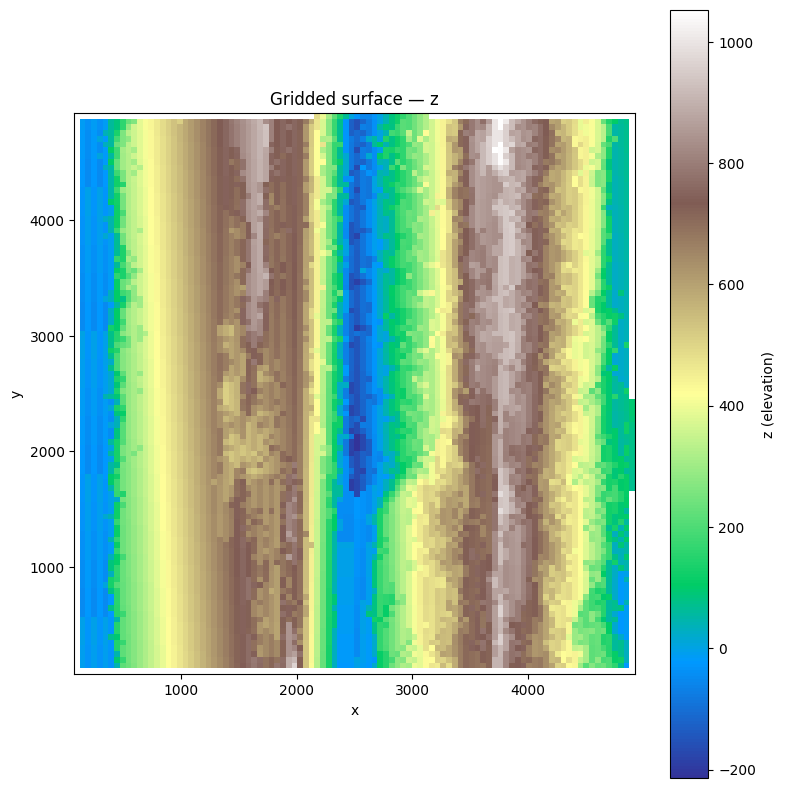

In [71]:
# plot z_grid to check

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(z_grid, cmap='terrain', origin='lower',
               extent=[synscape['x'].min(), synscape['x'].max(), synscape['y'].min(), synscape['y'].max()])
plt.colorbar(im, ax=ax, label='z (elevation)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Gridded surface — z')
plt.tight_layout()
plt.show()

In [77]:
# test loop
syn_scales = list(range(1, 11))            # [1, 2, ..., 10]
syn_degrees = list(range(0, 180, 5))  # [0, 5, 10, ..., 170, 175]
evamag_syn, evaphi_syn = compute_eva(z_grid, angles_deg, syn_scales, vc2)

In [74]:
print(f"output shape: {evamag_syn.shape}")
print(f"interior points computed: {(~np.isnan(evaphi_syn[:,:,0])).sum()}")
print(f"eva_mag1 range: {np.nanmin(evamag_syn):.4f} to {np.nanmax(evamag_syn):.4f}")
print(f"eva_phi1 unique values: {np.unique(evaphi_syn[~np.isnan(evaphi_syn)])}")

output shape: (98, 98, 5)
interior points computed: 7744
eva_mag1 range: 0.0000 to 22301.1597
eva_phi1 unique values: [  0.  30.  60.  90. 120. 150.]


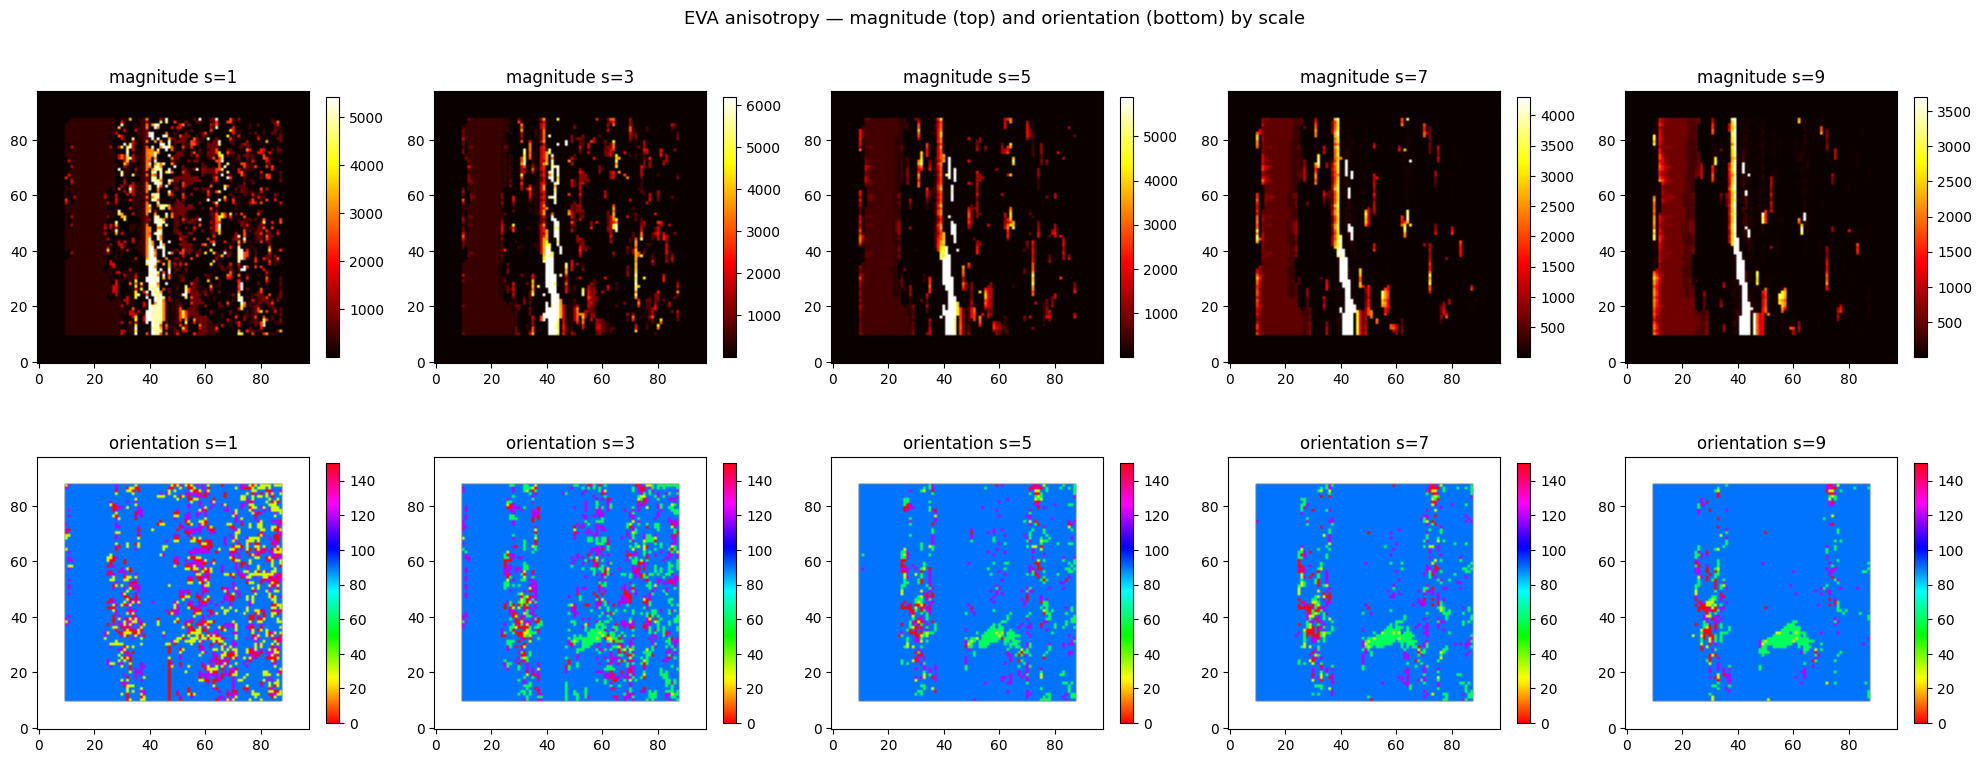

In [81]:
# plot anisotropy

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for s_idx, s in enumerate(syn_scales[0:-1:2]):
    # anisotropy magnitude
    arr_mag = evamag_syn[:, :, s_idx]
    vmin, vmax = np.nanpercentile(arr_mag[arr_mag != 0], [2, 98])
    im = axes[0, s_idx].imshow(arr_mag, cmap='hot', origin='lower',
                                vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=axes[0, s_idx], shrink=0.7)
    axes[0, s_idx].set_title(f'magnitude s={s}')

    # anisotropy orientation
    arr_phi = evaphi_syn[:, :, s_idx].copy()
    # arr_phi[arr_phi == 360] = np.nan  # mask uncomputed points
    im = axes[1, s_idx].imshow(arr_phi, cmap='hsv', origin='lower',
                                vmin=0, vmax=150)
    plt.colorbar(im, ax=axes[1, s_idx], shrink=0.7)
    axes[1, s_idx].set_title(f'orientation s={s}')

plt.suptitle('EVA anisotropy — magnitude (top) and orientation (bottom) by scale', fontsize=13)
plt.tight_layout()
plt.savefig('anis_clean.png')
plt.show()